# Modules

Does PANCAST assign elevated probability near locations where a convective core will initiate within the next 0–3 hours?

In [44]:
import sys
sys.path.insert(1, "../module")
import snflics

import numpy as np      

from netCDF4 import Dataset                             

import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt            

plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'

import warnings
warnings.filterwarnings("ignore")
import cartopy.io.shapereader as shpreader

import pandas as pd
from pathlib import Path

In [45]:
# load
geodata = np.load("/gws/nopw/j04/cocoon/SSA_domain/lat_lon_2268_2080.npz")

lons = geodata["lon"][:, :]
lats = geodata["lat"][:, :]

y_min, y_max = 48, 2062
x_min, x_max = 81, 2267

lats = lats[y_min:y_max+1, x_min:x_max+1]
lons = lons[y_min:y_max+1, x_min:x_max+1]

# $t_0$

In [46]:
year = "2023"
month = "08"
day = "01"
hour = "12"
minute = "00"

In [47]:
path_core_t0 = f'/gws/nopw/j04/cocoon/SSA_domain/ch9_wavelet/{year}/{month}'
file = f'{path_core_t0}/{year}{month}{day}{hour}{minute}.nc'

data = Dataset(file, mode='r')
temp_t0  = data["tir"][0, y_min:y_max+1, x_min:x_max+1]
cores_t0 = data["cores"][0, y_min:y_max+1, x_min:x_max+1]
binary_cores = (cores_t0 != 0).astype(int)

# Initiation at $t_0$

In [48]:
BASE_PATH = Path("/gws/nopw/j04/wiser_ewsa/mrakotomanga/initiations/txt_op")

COLUMNS = [
    "mo", "dy", "hr", "mn",
    "latN_c", "lonE_c",
    "i_c", "j_c", "i", "j",
    "topo_sd", "wf", "minT", "Rmax"
]

def load_month_file(filepath):
    year = int(filepath.name[5:9])
    month = int(filepath.name[9:11])

    df = pd.read_csv(
        filepath,
        delim_whitespace=True,
        skiprows=1,
        names=COLUMNS
    )

    df["year"] = year

    df["datetime"] = pd.to_datetime(
        dict(
            year=df["year"],
            month=df["mo"],
            day=df["dy"],
            hour=df["hr"],
            minute=df["mn"]
        ),
        utc=True
    )

    return df


def get_initiations_at_time(timestamp):
    timestamp = pd.to_datetime(timestamp, utc=True)

    filepath = BASE_PATH / f"init_{timestamp:%Y%m}_T40_vn3_30km.txt"

    if not filepath.exists():
        raise FileNotFoundError(f"Missing file: {filepath}")

    df = load_month_file(filepath)

    return df[df["datetime"] == timestamp]


In [49]:

timestamp = f"{year}-{month}-{day} {hour}:{minute}"

initiations = get_initiations_at_time(timestamp)

print(len(initiations))
print(initiations[["latN_c", "lonE_c", "minT", "Rmax"]])


10
    latN_c  lonE_c  minT  Rmax
76    0.61   30.94   -70   5.0
77    0.84   31.56   -68   3.4
78    0.89   26.70   -75   4.6
79    1.06   30.06   -75   3.2
80    2.00   27.78   -69   0.5
81    3.49   30.87   -68   4.6
82    6.71   11.54   -74  13.6
83   11.86    8.74   -50   0.6
84   15.75   27.03   -64   0.3
85   18.06   33.90   -78   4.6


# Loading nowcast at ground truth at a given valid time

In [50]:
from pathlib import Path
import torch

def load_nowcast_and_gt(year, month, day, hour, minute, lead_time):

    year   = int(year)
    month  = int(month)
    day    = int(day)
    hour   = int(hour)
    minute = int(minute)
    lead_time = int(lead_time)

    NOWCAST_ROOT = f"/gws/ssde/j25b/swift/mendrika/pancast/nowcasts/t{lead_time:03d}min"

    fpath = (
        f"{NOWCAST_ROOT}/"
        f"{year}{month:02d}/"
        f"{hour:02d}/"
        f"pred_{year}{month:02d}{day:02d}_{hour:02d}{minute:02d}.pt"
    )

    if not Path(fpath).exists():
        raise FileNotFoundError(fpath)

    data = torch.load(fpath, map_location="cpu")

    nowcast = data["mean"].numpy()
    gt = data["gt"].numpy()

    return nowcast, gt

In [51]:
print(year, month, day, hour, minute)

2023 08 01 12 00


In [52]:
lead_time = 30

nowcast, gt = load_nowcast_and_gt(year, month, day, hour, minute, lead_time)

In [53]:
nowcast_masked = np.ma.masked_where(nowcast == 0, nowcast)

In [54]:
import cartopy.geodesic as cgeo

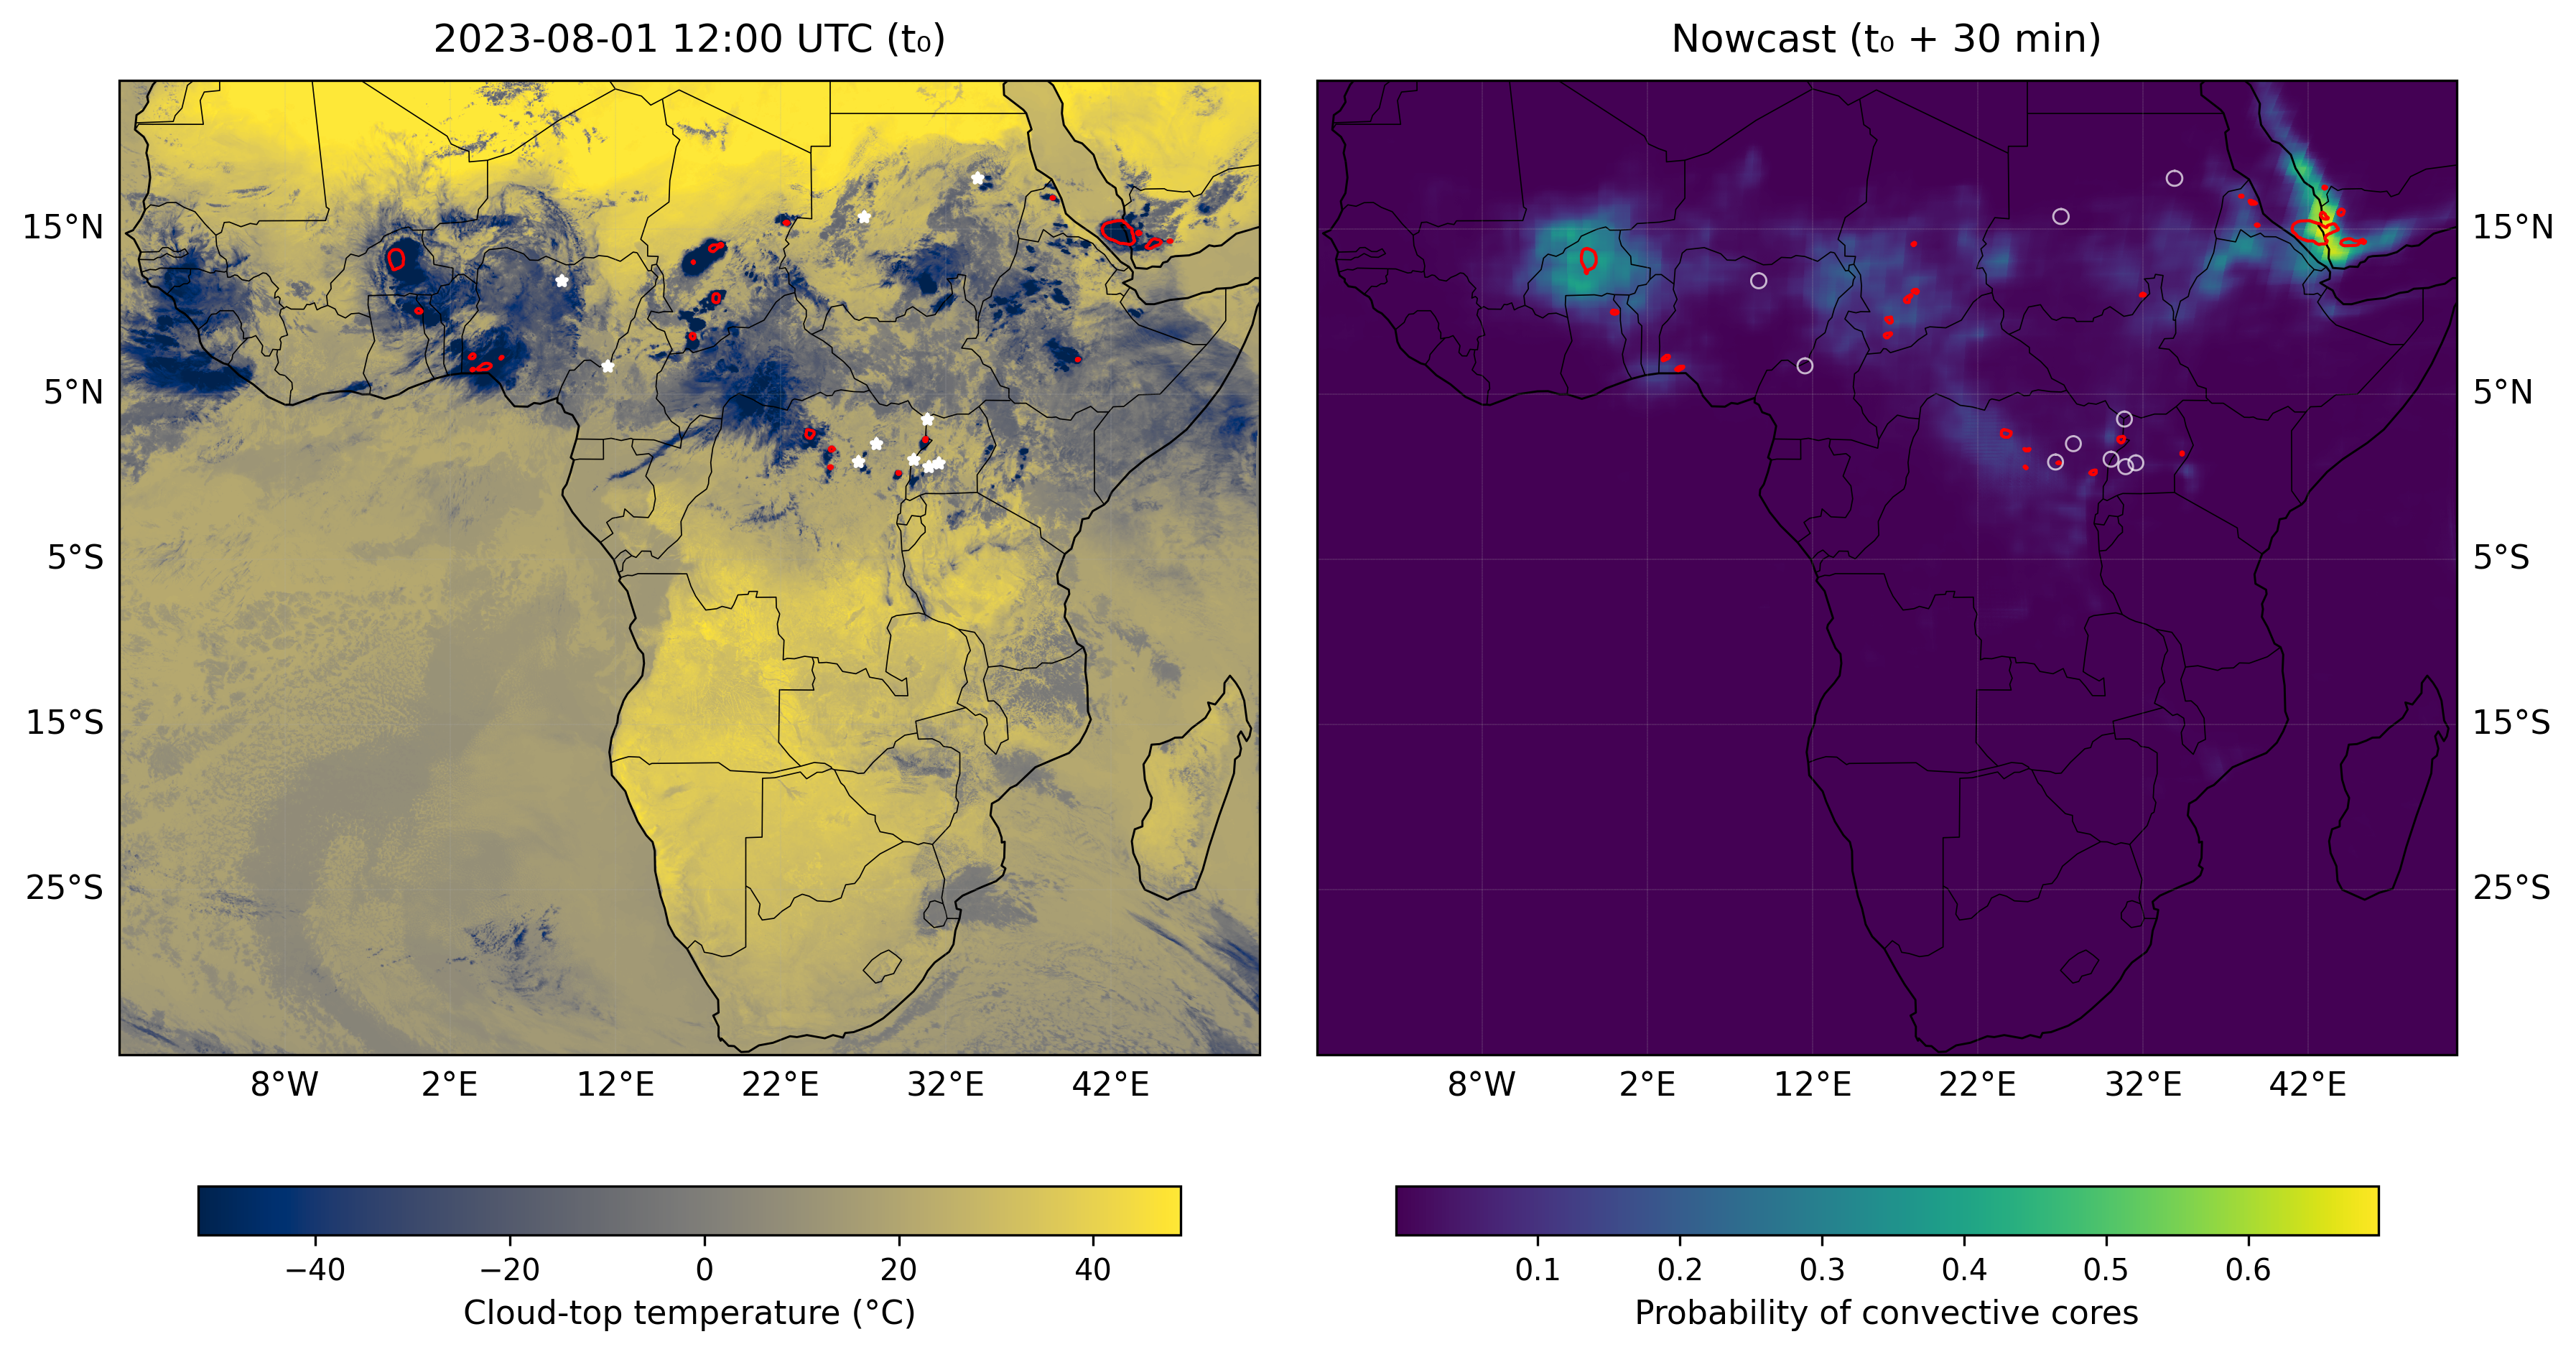

In [55]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 10),
    dpi=300,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

extent = (-18, 51, -35, 24)

for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.6)
    ax.add_feature(cfeature.OCEAN, facecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

# Gridlines: left panel shows left y labels, right panel shows right y labels
gl0 = axes[0].gridlines(
    draw_labels=True,
    linestyle="--",
    linewidth=0.1,
    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10),
)
gl0.top_labels = False
gl0.right_labels = False
gl0.left_labels = True
gl0.bottom_labels = True
gl0.xlabel_style = {"size": 11}
gl0.ylabel_style = {"size": 11}

gl1 = axes[1].gridlines(
    draw_labels=True,
    linestyle="--",
    linewidth=0.1,
    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10),
)
gl1.top_labels = False
gl1.left_labels = False
gl1.right_labels = True
gl1.bottom_labels = True
gl1.xlabel_style = {"size": 11}
gl1.ylabel_style = {"size": 11}

# -----------------------
# Left panel: t0
# -----------------------
ax0 = axes[0]

p0 = ax0.pcolormesh(
    lons,
    lats,
    temp_t0,
    cmap="cividis",
    vmin=np.nanpercentile(temp_t0, 1),
    vmax=np.nanpercentile(temp_t0, 97),
    shading="auto",
    zorder=1,
)

ax0.contour(
    lons,
    lats,
    cores_t0,
    levels=[0.5],
    colors="red",
    linewidths=1.0,
    zorder=3,
)

ax0.scatter(
    initiations["lonE_c"],
    initiations["latN_c"],
    s=10,
    marker="*",
    linewidths=1.5,
    color="white",
    transform=ccrs.PlateCarree(),
    zorder=4,
)

cb0 = plt.colorbar(
    p0,
    ax=ax0,
    orientation="horizontal",
    pad=0.08,
    fraction=0.03,
)
cb0.set_label("Cloud-top temperature (°C)", fontsize=11)

# -----------------------
# Right panel: t0 + 30 min
# -----------------------
ax1 = axes[1]

p1 = ax1.pcolormesh(
    lons,
    lats,
    nowcast_masked,
    cmap="viridis",
    shading="auto",
    zorder=1,
)

ax1.contour(
    lons,
    lats,
    gt,
    levels=[0.5],
    colors="red",
    linewidths=1.0,
    zorder=3,
)

geod = cgeo.Geodesic()
radius_m = 50_000

for lon0, lat0 in zip(init["lon"].values, init["lat"].values):
    circle = geod.circle(
        lon=float(lon0),
        lat=float(lat0),
        radius=radius_m,
        n_samples=120,
    )
    ax1.plot(
        circle[:, 0],
        circle[:, 1],
        color="white",
        linewidth=0.7,
        alpha=0.7,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

cb1 = plt.colorbar(
    p1,
    ax=ax1,
    orientation="horizontal",
    pad=0.08,
    fraction=0.03,
)
cb1.set_label("Probability of convective cores", fontsize=11)

ax0.set_title(
    f"{timestamp} UTC (t₀)",
    fontsize=13,
    pad=10,
)

ax1.set_title(
    f"Nowcast (t₀ + {lead_time} min)",
    fontsize=13,
    pad=10,
)

plt.subplots_adjust(wspace=0.05, bottom=0.12)
plt.show()

In [56]:
print(f"{year}{month}{day}-{hour}{minute}-{lead_time}min.png")

20230801-1200-30min.png


In [57]:
import numpy as np
from scipy.spatial import cKDTree

Ny, Nx = lats.shape

latlon_points = np.column_stack([
    lats.ravel(),
    lons.ravel(),
])

tree = cKDTree(latlon_points)

In [58]:
def map_ci_to_pan(lat_ci, lon_ci):
    dist, flat_idx = tree.query([lat_ci, lon_ci])
    j, i = np.unravel_index(flat_idx, (Ny, Nx))
    return j, i

In [60]:
ci_points = np.column_stack([
    initiations["latN_c"].values,
    initiations["lonE_c"].values,
])

dist, flat_idx = tree.query(ci_points)

j_ci, i_ci = np.unravel_index(flat_idx, (Ny, Nx))

In [61]:
print(j_ci, i_ci)

[1192 1200 1202 1208 1242 1295 1415 1601 1727 1798] [1713 1731 1585 1687 1618 1709 1070  964 1555 1734]


In [62]:
k = 0
print("CI:", initiations["latN_c"].iloc[k], initiations["lonE_c"].iloc[k])
print("PAN:", lats[j_ci[k], i_ci[k]], lons[j_ci[k], i_ci[k]])
print("Distance (deg):", dist[k])

CI: 0.61 30.94
PAN: 0.6145923 30.939217
Distance (deg): 0.0046586521351016565


In [63]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

In [ ]:
def evaluate_ci_event(
    j0, i0,
    lats, lons,
    core_truth,
    pancast_prob,
    R_km=50,
    half_window=40,
):
    Ny, Nx = lats.shape

    j1 = max(j0 - half_window, 0)
    j2 = min(j0 + half_window + 1, Ny)
    i1 = max(i0 - half_window, 0)
    i2 = min(i0 + half_window + 1, Nx)

    lat_win = lats[j1:j2, i1:i2]
    lon_win = lons[j1:j2, i1:i2]

    dist = haversine_km(
        lats[j0, i0],
        lons[j0, i0],
        lat_win,
        lon_win,
    )

    mask = dist <= R_km

    core_present = np.any(core_truth[j1:j2, i1:i2][mask] == 1)
    Pmax = np.nanmax(pancast_prob[j1:j2, i1:i2][mask])

    return core_present, Pmax

In [65]:
len(j_ci)

10

In [75]:
labels = []
scores = []

for k in range(len(j_ci)):
    y, s = evaluate_ci_event(
        j_ci[k],
        i_ci[k],
        lats,
        lons,
        gt,          # binary grid at t0+Δt
        nowcast,     # probability grid at t0+Δt
        R_km=50,
    )
    labels.append(y)
    scores.append(s)

labels = np.array(labels)
scores = np.array(scores)


In [76]:
scores

array([0.04012893, 0.04292608, 0.06009004, 0.02764457, 0.03187167,
       0.05357957, 0.01673732, 0.03699567, 0.01223488, 0.00989209],
      dtype=float32)

In [77]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(labels, scores)
print("AUC:", auc)

print("Median Pmax (core present):", np.median(scores[labels == 1]))
print("Median Pmax (no core):", np.median(scores[labels == 0]))


AUC: 1.0
Median Pmax (core present): 0.060090043
Median Pmax (no core): 0.03187167
